# Napistu meets PyTorch Geometric - Predicting Regulatory Interactions with Graph Neural Networks

In my previous post on the Octopus model, I demonstrated how Napistu integrates eight complementary pathway databases into a unified genome-scale network with ~50K proteins, metabolites, and complexes spanning ~10M edges. This multi-source integration preserves rich metadata about edge provenance, confidence scores, and mechanistic detail — creating a foundation far more comprehensive than the filtered subsets typically used in biological network analysis.

Biological applications of graph neural networks (GNNs) have typically worked with either:

- Small, curated gene regulatory or metabolic networks (100s-1,000s of nodes, 1,000s of interactions)
- Highly filtered subsets of the STRING database (~20K proteins, <1M edges at confidence score ≥500)

The Octopus sits in uncharted territory: **large enough to capture genome-scale complexity, yet structured enough to preserve the biological interpretability that makes network analysis valuable**. While recent work has demonstrated GNN scalability to 100M+ nodes in social networks, these methods remain largely unexplored for comprehensive biological networks that integrate regulatory, metabolic, and interaction data.
In this post, **I'll demonstrate that it's feasible to train graph convolutional networks on the complete Octopus network using just a laptop**.

<!--more-->

Specifically, I'll cover:

- **Data engineering**: Augmenting and encoding vertex and edge attributes from a `NapistuGraph` as PyTorch Geometric (PyG) `Data` objects, preserving the multi-source edge metadata that distinguishes the Octopus from single-database networks
- **Workflow management**: Setting up modular, reproducible pipelines for fitting and comparing multiple Graph Convolution Network (GCN) architectures with different embedding dimensions and training strategies
- **Self-supervised edge prediction**: Training without ground truth labels by framing the task as link prediction. The key challenge is forcing the model to learn real biological patterns through hard negative sampling—ensuring that negative examples aren't trivially distinguishable from true regulatory relationships
- **Network integration analysis**: Demonstrating that the learned representations successfully integrate the multi-source Octopus network. As I showed in the Octopus post, successful integration means vertices are "well-mixed"—proteins from different databases cluster together based on biological function rather than data source, indicating that the GNN has learned to synthesize information across the eight input databases

To support approaches like this I developed the [Napistu-Torch](https://github.com/napistu/napistu-torch) package which is available from [PyPI](https://pypi.org/project/napistu-torch/) and will be indexed by the [Napistu MCP server](https://www.shackett.org/napistu_mcp/).

## `NapistuGraph` -> `NapistuData`

To adapt a Napistu network (a `NapistuGraph`, which is a subclass of `igraph.Graph`) for PyG, we need to convert the graph to a PyG `Data` instance. The core components of this class are `torch.Tensor` objects:

- `x`: vertex attributes [# vertices x # of vertex features]
- `edge_index`: graph connectivity [2 x # of edges]
- `edge_attr` (optional): edge attributes [# edges x # of edge features]
- `edge_weight` (optional): edge weights [# of edges x  1]
- `y` (optional): Node labels for supervised learning tasks [generally, # of vertices x 1]

Following a similar strategy to (`NapistuGraph` : `igraph.Graph`) `napistu-torch` builds on `PyG` with non-standard attributes and Napistu-specific methods. My goal for this package is to lean on well-established frameworks like `PyG`, `PyTorch lightning` and `Weights and Biases` so the codebase can focus on adapting these to the biological network science domain.

### Creating a `NapistuData`

To construct a `NapistuData` instance we need to:

1. load a `NapistuGraph` (and its associated `SBML_dfs` database). This could be any biological network formatted for Napistu but here we'll be using the 8-source human consensus network (the Octopus). The Octopus can be downloaded from Google Cloud Storage (GCS) using either the Napistu-Py function `load_public_napistu_asset()` or the Napistu-Torch function `gcs_model_to_store` (demonstrated below).
2. add relevant vertex and edge attributes to the `NapistuGraph` as discussed in the [Octopus network post](https://www.shackett.org/octopus_network/#decorating-the--graph-with-species-and-reaction-data).  
3. encode vertex and edge attributes as `torch.Tensor`s. This is handled by the `napistu_graph_to_napistu_data` and more specialized underlying functions which handle support different splitting strategies (e.g., do we split edges or vertices into train, test and validation sets). Encoding leverages *sklearn* with custom logic for handling missing data and appropriate transformations can either be user-defined or automatically selected (e.g., passthrough for binary; one-hot for multiclass; normal for continuous data).

Rather than walking through the creation of a single `NapistuData` piecewise, (which few would care to see), I'll construct it along with related artifacts using the `NapistuDataStore` which is a more accessible point-of-entry for most users and what is used as part of config-driven model training. But, before getting to that, I'll show how to reproduce this post, import packages, and set global parameters.

#### Environment setup

To reproduce this notebook:

1. Install [uv](https://docs.astral.sh/uv/#highlights) (or use `pip` if preferred)

2. Setup a Python environment:

```bash
uv venv --python 3.11
source .venv/bin/activate
# Core dependencies
uv pip install torch==2.8.0
uv pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cpu.html
uv pip install napistu==0.7.5
uv pip install "napistu-torch[pyg,lightning]==0.2.5"
# if you'd like to render the notebook, you'll need to install these additional dependencies
uv pip install seaborn ipykernel nbformat nbclient umap-learn
python -m ipykernel install --user --name=blog-staging
```

3. Download the [`napistu_nets.qmd`](https://github.com/shackett/shackett/blob/master/posts/posted/napistu_nets.qmd) notebook (or copy and paste the relevant code blocks)

4. Configure `EXPERIMENTS_DIR` and other paths in the setup code block to point to locations where you're comfortable saving raw data and results

5. Download model configs (If you want to train models)

#### Configure imports and glboal parameters


In [1]:
# imports

import logging
import os
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from napistu_torch.evaluation.edge_prediction import summarize_edge_predictions_by_strata
from napistu_torch.evaluation.edge_weights import compute_edge_feature_sensitivity, get_edge_encoder
from napistu_torch.evaluation.evaluation_manager import EvaluationManager
from napistu_torch.evaluation.model_comparison import compare_embeddings
from napistu_torch.evaluation.pathways import calculate_pathway_similarities
from napistu_torch.lightning.workflows import predict
from napistu_torch.load.gcs import gcs_model_to_store
from napistu_torch.utils.torch_utils import select_device
from napistu_torch.visualization.basic_metrics import plot_model_comparison
from napistu_torch.visualization.embeddings import layout_umap, plot_coordinates_with_masks

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("napistu_torch")

# globals

OVERWRITE = False

EXPERIMENTS_DIR = Path(os.path.expanduser("~/Desktop/EXPERIMENTS/20251106_edge_prediction"))

EXPERIMENTS = [
    # leave this as a list so it defines plot order
    "20251106_gcn_baseline",
    "20251106_gcn_edge_encoding",
    "20251106_sage_baseline",
    "20251106_graphconv_baseline",
    "20251106_graphconv_edge_encoding"
]

EXPERIMENT_LABELS = {
    "20251106_gcn_baseline" : "GCN",
    "20251106_gcn_edge_encoding" : "GCN + Edge Encoding",
    "20251106_sage_baseline" : "SAGE",
    "20251106_graphconv_baseline" : "GraphConv",
    "20251106_graphconv_edge_encoding" : "GraphConv + Edge Encoding"
}

ordered_labels = [EXPERIMENT_LABELS[exp] for exp in EXPERIMENTS]

CACHE_DIR = EXPERIMENTS_DIR
TOP_MODEL_NAME = "GraphConv + Edge Encoding"
EMBEDDING_COMPARISONS_PATH = CACHE_DIR / "embedding_comparisons.tsv"

# validation
if not os.path.isdir(EXPERIMENTS_DIR):
    raise FileNotFoundError(f"Experiments directory not found: {EXPERIMENTS_DIR}")
if not os.path.isdir(CACHE_DIR):
    raise FileNotFoundError(f"Cache directory not found: {CACHE_DIR}")

/Users/sean/Desktop/GITHUB/shackett/posts/staging/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Managing raw and derived artifacts with `NapistuDataStore`

Loading an `SBML_dfs` database takes a few minutes so its a good idea to cache derived artifacts so they can be quickly loaded. The `NapistuDataStore` allows for this by managing a registry of existing derived artifacts and simplifying the reconstruction and caching of requested artifacts. A set of named artifacts are defined in the `napistu_torch.load.artifacts` module to support common workflows and simplify integration with configs.

I'll leverage the store here to load the artifacts which are required by this notebook. Handily, a store can be initialized directly from one of the bundled Napistu networks from GCS using `gcs_model_to_store`. This will create and reuse two local directories:

- `napistu_data_dir` defines where raw data (including the `NapistuGraph` and `SBML_dfs`) should be saved
- `store_dir` is the directory where `NapistuDataStore` will maintain its registry file and all of the artifacts that it is managing.

In [2]:
napistu_data_store = gcs_model_to_store(
    napistu_data_dir = "./napistu_data",
    store_dir = "./store",
    asset_name = "human_consensus",
    asset_version = "20250923" # pin to a stable version of the dataset for reproducibility
)

Using the `NapistuDataStore` we can create and save all of the artifacts needed for training and evaluating the models. These artifacts are:

- **edge_prediction** - an unlabeled `NapistuData` instance with edges distinguished with a `train_mask`, `val_mask` and `test_mask`.
- **comprehensive_pathway_memberships** - detailed source information for each vertex. When encoding vertex features, whether a vertex is associated with each of the 8 sources in the Octopus model is defined with just 8 binary features. But, the Reactome pathway is really comprised of many smaller sources (~2,500 separate pathways). This artifact captures ALL of the pathways a vertex is associated with for the purposes of model evaluation.
- **edge_strata_by_node_type** - this saves and loads a pd.Series containing the "from" node_type and the "to" node_type of each edge. As I'll show, this is important for negative sampling because some types of edges are impossible (reaction -> reaction) and the strata define categories to use for sampling plausible negatives.
- **edge_strata_by_node_species_type** - this is similar to **edge_strata_by_node_type** but separates edges into categories based on the "from" node_type & species_type (e.g., protein, regulatory RNA, metabolite) and the "to" node_type and species_type. This can be used for negative sampling as well but its also useful for validating edge predictions to assess whether the model is systematically biased towards particular kinds of interactions.

The `ensure_artifacts` checks whether the requested artifacts already exists and if they do not, it loads both the `SBML_dfs` (`load_sbml_dfs()`) and `NapistuGraph` (`load_napistu_graph()`), and then constructs and saves each missing artifact. 

In [3]:
napistu_data_store.ensure_artifacts([
    "edge_prediction",
    "comprehensive_pathway_memberships",
    "edge_strata_by_node_type",
    "edge_strata_by_node_species_type"
])

INFO:napistu_torch.napistu_data_store:All requested artifacts already exist in store


Now, these artifacts can be easily accessed and quickly loaded (all four artifacts load in ~4 seconds!).

In [4]:
napistu_data = napistu_data_store.load_napistu_data("edge_prediction")
comprehensive_pathway_memberships = napistu_data_store.load_vertex_tensor("comprehensive_pathway_memberships")
edge_strata_by_node_type = napistu_data_store.load_pandas_df("edge_strata_by_node_type")
edge_strata_by_node_species_type = napistu_data_store.load_pandas_df("edge_strata_by_node_species_type")

INFO:napistu_torch.napistu_data_store:Loading NapistuData from store/napistu_data/edge_prediction.pt
INFO:napistu_torch.napistu_data_store:Loading VertexTensor from store/vertex_tensors/comprehensive_pathway_memberships.pt
INFO:napistu_torch.napistu_data_store:Loading pandas DataFrame from store/pandas_dfs/edge_strata_by_node_type.parquet
INFO:napistu_torch.napistu_data_store:Loading pandas DataFrame from store/pandas_dfs/edge_strata_by_node_species_type.parquet


With the `NapistuDataStore` in place, I can now specify just a path to the store and the required artifacts can be loaded on-demand (and built only when necessary). This speeds up development and experimentation. It also provides a layer of abstraction away from the actual `Napistu-Py` codebase. Napistu-Py logic is baked into `Napistu-Torch` objects which can be used as-is without users needing to concern themselves with `Napistu-Py` (unless they want to; its really cool ;).

## Anatomy of a GNN

Training a GNN requires coordinating several components: the model architecture itself, the task definition, data management, and training infrastructure. This section breaks down these components and shows how they work together in Napistu-Torch.

### System Architecture
```mermaid
graph TB
    subgraph "Core Components"
        T[TaskEdgePrediction] --> M[ModelEncoder + Head]
        D[DataModuleGraph Data + Batching] --> TR[TrainerOptimization + Logging]
        M --> TR
        T -.Defines Loss & Metrics.-> TR
    end
    
    C[ExperimentConfigYAML] --> T
    C --> M
    C --> D
    C --> TR
    
    TR --> O[Trained Model+ Checkpoints]
    
    style C fill:#e1f5ff
    style O fill:#e1ffe1
    style T fill:#fff4e1
    style M fill:#ffe1f0
    style D fill:#f0e1ff
    style TR fill:#e1ffe1
```

The **Task** defines what we're learning (edge prediction), the **Model** implements the architecture (encoder + head), the **DataModule** manages graph data and batching, and the **Trainer** orchestrates the training loop. An **ExperimentConfig** ties everything together, making it easy to run different experiments by changing a YAML file.

In the following subsections, we'll examine each component in detail, starting with the task definition and then exploring the model architecture.


### Task: what are we trying to predict?

At the highest level, a GNN task defines the learning objective—what predictions we want the model to make and how we'll evaluate its performance. Different tasks require different architectural components and training strategies. Common GNN tasks include node classification (predicting properties of individual nodes), graph classification (predicting properties of entire graphs), and link prediction (predicting whether edges should exist between nodes).

#### Edge prediction in Napistu-Torch

For this analysis, we're using the edge prediction task (also called link prediction). The goal is to predict whether an edge should exist between two nodes in a biological network. This is particularly valuable for discovering potential protein-protein interactions, metabolic relationships, or regulatory connections that may be missing from current databases. Edge prediction is also self-supervised so it doesn't require vertrex or edge labels, which are often difficult to create or overly contrived.

The training process works by teaching the model to discriminate between:
- Positive edges: Real edges that exist in the training set
- Negative edges: Node pairs that are sampled as non-edges (carefully chosen to avoid real edges)

In Napistu-Torch, the `EdgePredictionTask` class orchestrates this process. It handles negative sampling, computes the loss function (binary cross-entropy), and evaluates performance using metrics like AUC and average precision. The task operates in a transductive setting, where the model sees the full graph structure but only learns from a subset of edges marked for training, while validation and test edges are held out to prevent information leakage.

{ % include ai-aside.html content="
negative sampling 
" %}

With the task defined, let's examine the three core model components: the encoder that learns node embeddings, the head that produces predictions, and the optional edge encoder that can weight message passing.

### Encoder: learning vertex representations

The encoder is the core of a GNN — it transforms raw node features into learned embeddings by aggregating information from each node's local neighborhood. Through multiple layers of message passing, encoders capture increasingly complex patterns of connectivity and feature similarity. The encoder's architecture determines how information flows through the graph and what kinds of structural patterns the model can learn.

#### Message passing encoders in Napistu-Torch

Napistu-Torch implements several popular message passing architectures through the MessagePassingEncoder class:

- GraphSAGE (SAGE) and GraphConv: These architectures sample and aggregate features from a node's neighbors using various aggregation functions (mean, max, add). Both are efficient and scale well to large graphs, making them excellent choices for biological networks. GraphConv is similar to SAGE but uses a simplified message passing scheme. The key distinction is that GraphConv can optionally support edge weighting—allowing the model to modulate message passing strength based on learned or static edge weights—while SAGE uses uniform edge weights.
- Graph Convolutional Networks (GCN): Uses a normalized aggregation scheme based on graph structure, applying a symmetric normalization that accounts for node degrees. GCN also supports edge weighting, which can be particularly useful when some edges are more reliable or important than others.

All encoders in Napistu-Torch follow a multi-layer architecture, progressively refining node embeddings through repeated neighborhood aggregation. The framework provides a unified interface for these encoders, allowing easy experimentation through configuration files without changing code.

### Head/decoder: making predictions from embeddings

Once the encoder has produced node embeddings, the head (or decoder) transforms these embeddings into task-specific predictions. For edge prediction, the head takes embeddings of two nodes and produces a score indicating how likely an edge should exist between them. Different head architectures offer different trade-offs between expressiveness, computational cost, and interpretability.

#### Edge prediction heads in Napistu-Torch

Napistu-Torch provides three decoder options for edge prediction through the Decoder class:

- Dot Product: Computes the inner product of source and target node embeddings. This is the simplest and most efficient head—it assumes that nodes with similar embeddings should be connected. Despite its simplicity, dot product heads often perform surprisingly well and serve as a strong baseline.
- MLP (Multi-Layer Perceptron): Concatenates source and target embeddings and passes them through a feedforward neural network. This is more expressive than dot product, allowing the model to learn non-linear relationships between node pairs, but requires more parameters and computation.

For this analysis, I'll only use the dot product head due to its efficiency on large biological networks, though Napistu-Torch makes it easy to swap in more complex heads through configuration changes. 

{ % include ai-aside.html content="
A key limitation of the dot product is that its symmetric between the from- and to-vertex making it more suitable for predicting interactions rather than regulation. In the future, I'll explore asymmetric heads like the MLP, or RotatE. 

Relation-aware heads
" %}

### Edge encoder: weighting message passing

A unique feature of Napistu-Torch is its flexible edge encoding system. While many GNN implementations either ignore edge attributes entirely or only accept a single edge weight, biological networks often have rich edge metadata—for example, confidence scores from different databases, interaction types, or experimental evidence codes. The challenge is that most message passing architectures (like SAGE) don't support edge attributes at all, while others (like GCN and GraphConv) only accept a single scalar weight per edge.

#### Learned edge weighting in Napistu-Torch

Napistu-Torch solves this through the `EdgeEncoder` class, which compresses multi-dimensional edge attributes into a single learned weight that modulates message passing strength. The edge encoder is a lightweight MLP that takes edge features as input and outputs a scalar weight in [0, 1] via sigmoid activation. These learned weights then control how strongly each edge contributes during neighborhood aggregation.

This approach offers several advantages:

- *Flexibility*: Works with any edge features (continuous, categorical, or mixed)
- *Trainability*: The encoder learns which edge attributes are most predictive for the task
- *Compatibility*: Produces the single scalar weight that GCN/GraphConv expect
- *Efficiency*: Uses a small network (~edge_dim × 32 parameters) that trains end-to-end

The edge encoder essentially learns to filter noisy edges and amplify reliable ones, allowing the model to focus message passing on the most informative connections. This is particularly valuable in biological networks where edge quality varies significantly across data sources.

### Model overview

```mermaid
graph LR
    A[Node Features] --> C[Message Passing<br/>Encoder<br/>SAGE/GCN/GraphConv]
    C --> D[Node Embeddings]
    D --> E[Head/Decoder<br/>Dot Product/MLP/Bilinear]
    E --> F[Edge Predictions/<br/>Vertex Classification]
    
    G[Edge Index] --> C
    H[Edge Attributes] -.-> B[Edge Encoder<br/>Optional]
    B -.-> C
    
    style B fill:#ffd,stroke:#333,stroke-width:2px,stroke-dasharray: 5 5
    style H fill:#ffd,stroke:#333,stroke-width:2px,stroke-dasharray: 5 5
```

The optional edge encoder (shown in dashed lines with yellow background) learns to weight edges based on edge attributes, modulating how strongly each edge contributes during message passing. This is particularly useful when edge reliability varies or when certain edge types should have stronger influence on node embeddings.

These model components (encoder, head, edge encoder) define the core prediction logic, but training a GNN requires additional infrastructure to manage data loading, optimization, and evaluation. Napistu-Torch uses PyTorch Lightning to orchestrate this training workflow.

### PyTorch lightning: orchestrating training infrastructure

Before diving into data configuration, it's important to understand how Napistu-Torch organizes the training workflow. While the core GNN components (encoder, head, task) are pure PyTorch, actually training a model requires substantial boilerplate: optimizer setup, learning rate scheduling, checkpoint saving, logging metrics, handling different hardware accelerators, and coordinating training/validation loops.

#### Lightning Integration in Napistu-Torch

Napistu-Torch uses PyTorch Lightning to handle all this training infrastructure automatically. Lightning separates the scientific code (model architecture, loss functions) from engineering code (training loops, GPU management), making experiments more reproducible and less error-prone.

The key Lightning components in Napistu-Torch are:

- LightningModule: Wraps the core task (encoder + head) and defines training/validation steps, metrics computation, and optimizer configuration. Napistu-Torch provides task-specific adapters like EdgePredictionLightning that bridge pure PyTorch task implementations with Lightning's training infrastructure.
- Trainer: The orchestrator that runs the actual training loop, handles checkpointing, manages multiple GPUs/devices, integrates with experiment tracking tools like Weights & Biases, and implements callbacks like early stopping.

This architecture means you can focus on defining your model and task logic while Lightning handles the messy details of distributed training, mixed precision, gradient accumulation, and more.

### DataModule: managing graph data and batching

The NapistuDataModule is Lightning's interface for data loading, and it plays a crucial role in how the model trains. It can be initialized directly from an `ExperimentConfig`, automatically handling artifact loading, data validation, and dataloader creation.

#### Initialization and artifacts

When you create a `NapistuDataModule` from a config, it:

1. Loads or creates a NapistuDataStore containing all graph data and preprocessing artifacts
2. Loads the specified NapistuData object (the actual graph with features, edges, and train/val/test masks)
3. Retrieves any additional artifacts needed for the task (e.g., edge stratification data for negative sampling)
4. Validates that all required data is present and properly formatted

#### Full-batch vs. mini-batch Training

In practice, the trainer interfaces with subclasses of `NapistuDataModule` which define how to load a batch of training or validation data.

Napistu-Torch provides two DataModule implementations that handle fundamentally different training strategies:

- `FullGraphDataModule`: Returns the complete graph in each batch. The model processes all training edges simultaneously, computing a single gradient update per epoch. This is simple and works well for smaller graphs, but can be memory-intensive and may lead to slow convergence since the model only updates once per epoch regardless of graph size.
- `EdgeBatchDataModule`: Splits training edges into mini-batches while still loading the entire graph structure for message passing. Each batch only computes loss and gradients on a subset of training edges, but uses the full graph for neighborhood aggregation. This enables multiple gradient updates per epoch without increasing memory requirements — you're not loading the graph multiple times, just subdividing the supervision signal. This leads to faster convergence and more stable training, especially on large biological networks.

For this analysis on a large biological network, we'll use EdgeBatchDataModule with 20 batches per epoch. This means the model updates its weights 20 times per epoch rather than just once, allowing for more responsive learning without the memory overhead of processing all edges simultaneously.

## Workflow management

In this post, I'll be comparing 5 models:

- GraphConv (+/- edge encoding)
- GCN (+/- edge encoding)
- SAGE (edge encoding not supported).

These models are NOT optimized but they used the same hyperparameters (all trained to 200 epochs, same number of batches per epoch, same encoder hidden dimension) so it should be a fair albeit far from comprehensive comparison.

If you want to train the same models you can download the configs and a simple shell script to run them [here](https://github.com/shackett/shackett/blob/main/assets/data/napistu_nets_configs.zip).

To efficiently and reproducibly train these models (and many more in the future!) I needed a workflow which was:

- Easy to configure, modular, and extendable

    This is accomplished with an `ExperimentConfig` which can be defined with a minimal YAML config and composed with defaults to capture how an experiment should be conducted. Its composed of a set of lower-level Pydantic configs, `DataConfig`, `ModelConfig`, `TaskConfig`, `WandBConfig`, and `TrainerConfig` providing sensible defaults and up-front validation.

- Able to run from the command line

    This is supported by the Napistu-Torch CLI 

    ```bash
    napistu-torch train graphconv_baseline.yaml --out-dir 20251106_graphconv_baseline
    napistu-torch test 20251106_graphconv_baseline
    ```

- Accurately tracks experiments that have occurred

    Training, validation and test metrics are logged to Weights & Biases (W&B) to easily summarize and compare experiments. These measures can be recovered (as shown below) just from the W&B. The W&B run ID and the `ExperimentConfig` (with all defaults added) are incorporated into a `RunManifest` which is saved to the model's output directory (alongside its checkpoints and logs).  

Having fitted each of these models using configs above and the Napistu-Torch CLI I will now load and compare these models.

## Model comparison

To simplify model evaluation, Napistu-Torch has an `EvaluationManager` class which loads the `RunManifest` and provides convenient methods for loading the best checkpoint, the `NapistuDataStore` avoid some of the overhead of tracking paths. Using these managers, I'll first recover all of the training, validation, and test summaries for each of the models and visualize them side-by-side.

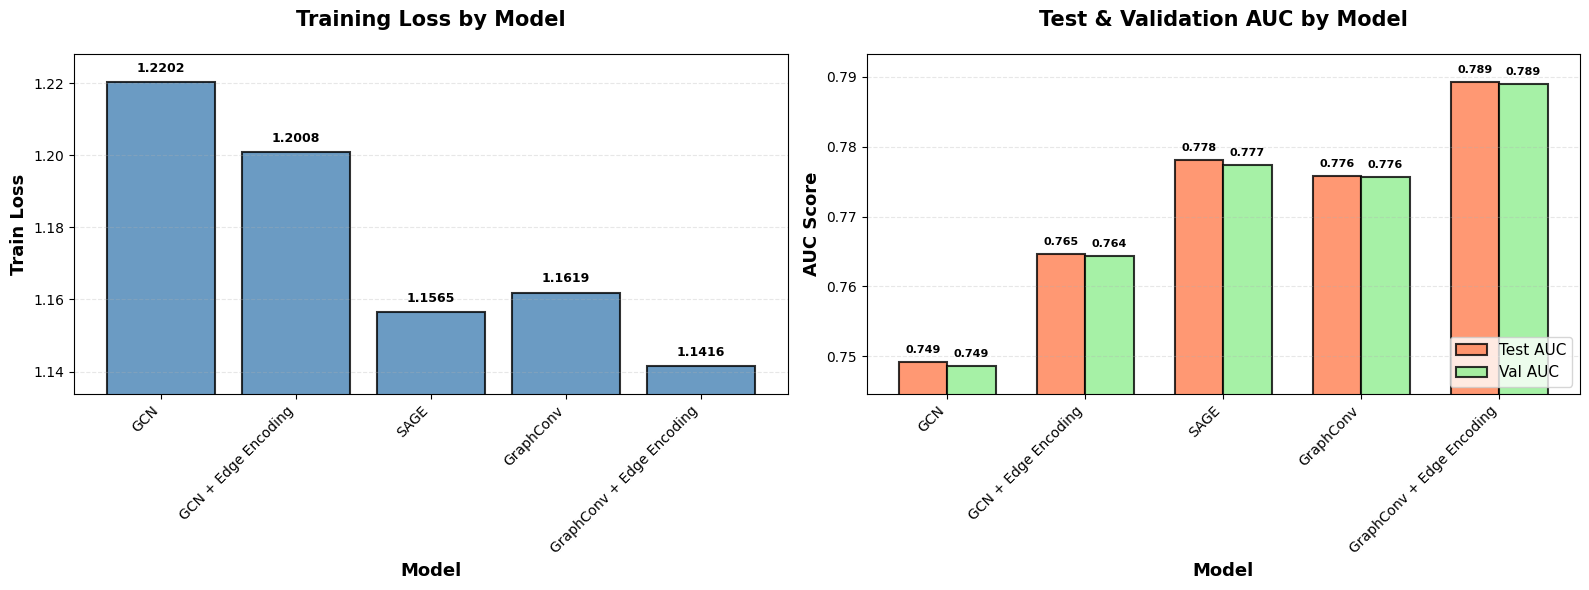

In [5]:
eval_managers = {
    EXPERIMENT_LABELS[out_dir]: EvaluationManager(EXPERIMENTS_DIR / out_dir) for out_dir in EXPERIMENTS
}

# Extract models summaries directly from W&B using their API
run_summaries = {exp: manager.get_run_summary() for exp, manager in eval_managers.items()}

# visualize model comparison
fig, (ax1, ax2) = plot_model_comparison(run_summaries, ordered_labels)
plt.show()

Here, the train loss is the binary cross entropy based on an equal number of training edges (70% of the network) compared to negative sampled edges. The validation AUC defines how readily real edges (15% of the network), which existed in the network but were not used for message passing during training, rank higher than an equal number of negative sampled edges. The validation AUC is evaluated after each epoch to track the best checkpoint and assess whether early stopping should kick in. The test AUC assesses how readily the remaining real edges (15% of the network) rank above negative sampled edges post-training.

These models performances are not radically different and I'll table the discuss of whether they are good or bad, but clear trends do emerge. In terms of the encoders: SAGE > GraphConv >> GCN; and using edge encoders improves edge prediction.

To explore these models more deeply, I'll extract and compare their vertex embeddings and where appropriate their learned edge weights.

In [6]:
top_model_manager = eval_managers[TOP_MODEL_NAME]
napistu_data = top_model_manager.load_napistu_data()
napistu_data_store = top_model_manager.get_store()
napistu_graph = napistu_data_store.load_napistu_graph()

# pull out the node types and create a mask to distinguish species and reactions
node_types = napistu_graph.get_vertex_series("node_type")
is_species_mask = (node_types == "species").values

## Extract model embeddings
edge_encodings = {}
species_embeddings = {}
for exp, evaluation_manager in eval_managers.items():
    # load the model and data
    model = evaluation_manager.load_model_from_checkpoint()
    napistu_data = evaluation_manager.load_napistu_data()
    
    # pull out learned edge weights (if an edge encoder is present)
    if model.task.encoder.edge_weighting_type == "learned_encoder":
        edge_encodings[exp] = model.get_learned_edge_weights(napistu_data)
    
    # pull out the vertex embeddings
    embeddings = model.get_embeddings(napistu_data)
    species_embeddings[exp] = embeddings[is_species_mask]

    # cleanup
    evaluation_manager.experiment_dict = None

INFO:napistu_torch.napistu_data_store:Loading NapistuData from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store/napistu_data/edge_prediction.pt
INFO:napistu_torch.ml.wandb:Resuming W&B run: hzeu5a8n
wandb: Currently logged in as: shackett (napistu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


INFO:napistu_torch.ml.wandb:Successfully resumed W&B run: https://wandb.ai/napistu/napistu-experiments/runs/hzeu5a8n
INFO:napistu_torch.lightning.workflows:Creating EdgeBatchDataModule with batches_per_epoch = 20...
INFO:napistu_torch.lightning.datamodule:Creating/loading store from config
INFO:napistu_torch.napistu_data_store:Loading existing store from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store
INFO:napistu_torch.napistu_data_store:Ensuring required artifacts exist: ['edge_strata_by_node_species_type', 'edge_prediction', 'edge_strata_by_node_type', 'comprehensive_pathway_memberships']
INFO:napistu_torch.napistu_data_store:All requested artifacts already exist in store
INFO:napistu_torch.napistu_data_store:All requested artifacts already exist in store
INFO:napistu_torch.lightning.datamodule:Loading napistu_data 'edge_prediction' from store
INFO:napistu_torch.napistu_data_store:Loading NapistuData from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-

## Comparing vertex embeddings

To compare the model's molecular species embeddings, I extracted each embedding (# species x hidden dimension) and calculated the species-species cosine similarities. Then I calculated the Spearman correlation of vertex similarities between pairs of models. While in this analysis all of the compared models have the same hidden dimension this approach would allow me to compare models with different hidden dimensions. Comparing vertex similarities also avoids the need to directly align embeddings, e.g., by Procrustes rotation. 

In [7]:
OVERWRITE = False
if os.path.isfile(EMBEDDING_COMPARISONS_PATH) and not OVERWRITE:
    embedding_comparisons = pd.read_csv(EMBEDDING_COMPARISONS_PATH, sep="\t", index_col=0)
else:
    device = select_device(mps_valid = True)
    embedding_comparisons = compare_embeddings(species_embeddings, device)
    embedding_comparisons.to_csv(EMBEDDING_COMPARISONS_PATH, sep="\t", index_col=False)


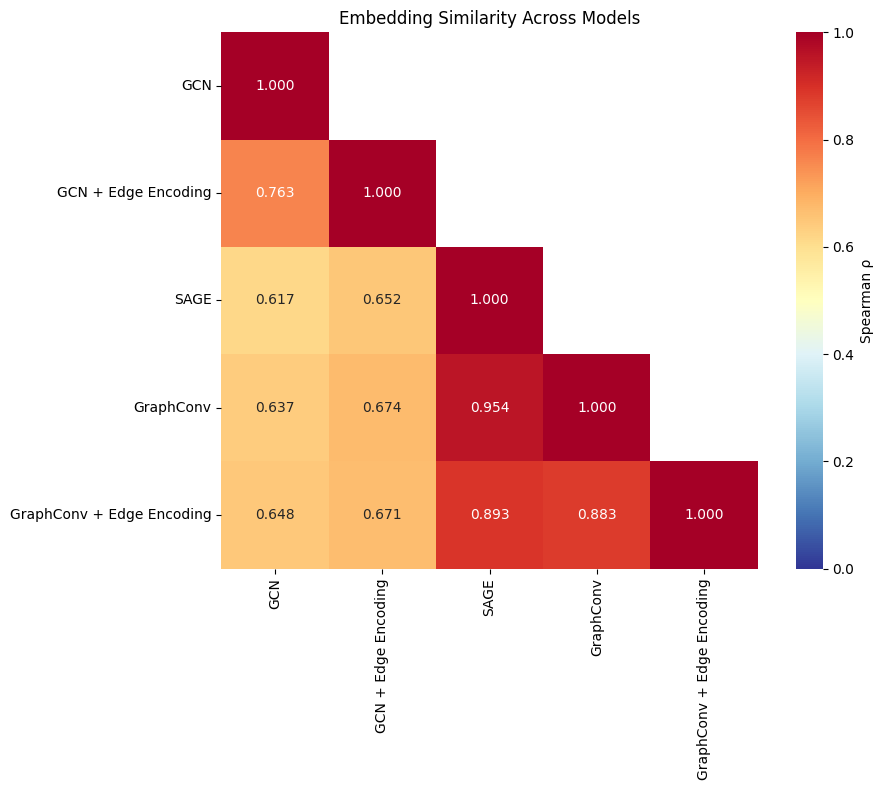

In [8]:
def create_correlation_heatmap(embedding_comparisons: pd.DataFrame, 
                               model_order: list[str] | None = None) -> pd.DataFrame:
    """
    Convert pairwise comparison results into a symmetric correlation matrix.
    
    Parameters
    ----------
    embedding_comparisons : pd.DataFrame
        DataFrame with columns: model1, model2, spearman_rho
    model_order : list[str] | None
        Optional list specifying the order of models in the matrix.
        If None, models are sorted alphabetically.
        
    Returns
    -------
    corr_matrix : pd.DataFrame
        Symmetric correlation matrix with models as both index and columns
    """
    # Get all unique models
    all_models = set(embedding_comparisons['model1'].unique()) | \
                 set(embedding_comparisons['model2'].unique())
    
    # Use provided order or default to sorted
    if model_order is None:
        models = sorted(all_models)
    else:
        # Validate that all models in data are in the provided order
        missing_models = all_models - set(model_order)
        if missing_models:
            raise ValueError(f"Models in data but not in model_order: {missing_models}")
        # Use only models that exist in the data, in the specified order
        models = [m for m in model_order if m in all_models]
    
    # Initialize matrix with 1s on diagonal
    corr_matrix = pd.DataFrame(np.eye(len(models)), 
                               index=models, 
                               columns=models)
    
    # Fill in the correlations (both upper and lower triangles)
    for _, row in embedding_comparisons.iterrows():
        corr_matrix.loc[row['model1'], row['model2']] = row['spearman_rho']
        corr_matrix.loc[row['model2'], row['model1']] = row['spearman_rho']
    
    return corr_matrix

corr_matrix = create_correlation_heatmap(embedding_comparisons, model_order=ordered_labels)

# Display as heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', 
            mask=mask, vmin=0, vmax=1, square=True, 
            cbar_kws={'label': 'Spearman ρ'})
plt.title('Embedding Similarity Across Models')
plt.tight_layout()
plt.show()

From this output, its apparent that all of the vertex embeddings cluster features in a similar way though the encoder architecture (GCN vs GraphConv/SAGE) has a moderate impact on the overall structure of the embedding.

## Comparing learned edge weights

As I've [previously discussed](https://www.shackett.org/octopus_network/#decorating-the--graph-with-species-and-reaction-data) our confidence in regulatory interactions varies greatly and this confidence can be baked into many network-based approaches using edge weights. However determining appropriate edge weights is challenging when we have multiple data sources attributes which capture some ntion of believability.

An interesting feature of Napistu-Torch is the ability to learn "what makes a high confidence edge" empirically. I'll go over what makes a good edge later on, but for now, I will assess whether the learned edge weights are preserved across models by directly compare the edge weights from the GCN + edge encoding and GraphConv + edge encodings models.

Since there are ~10M edges I'll compare paired edge weights using a hexbin plot (i.e., a bivariate histogram) and use a logit transformation to convert the sigmoidal weights back to the $\mathbb{R}$

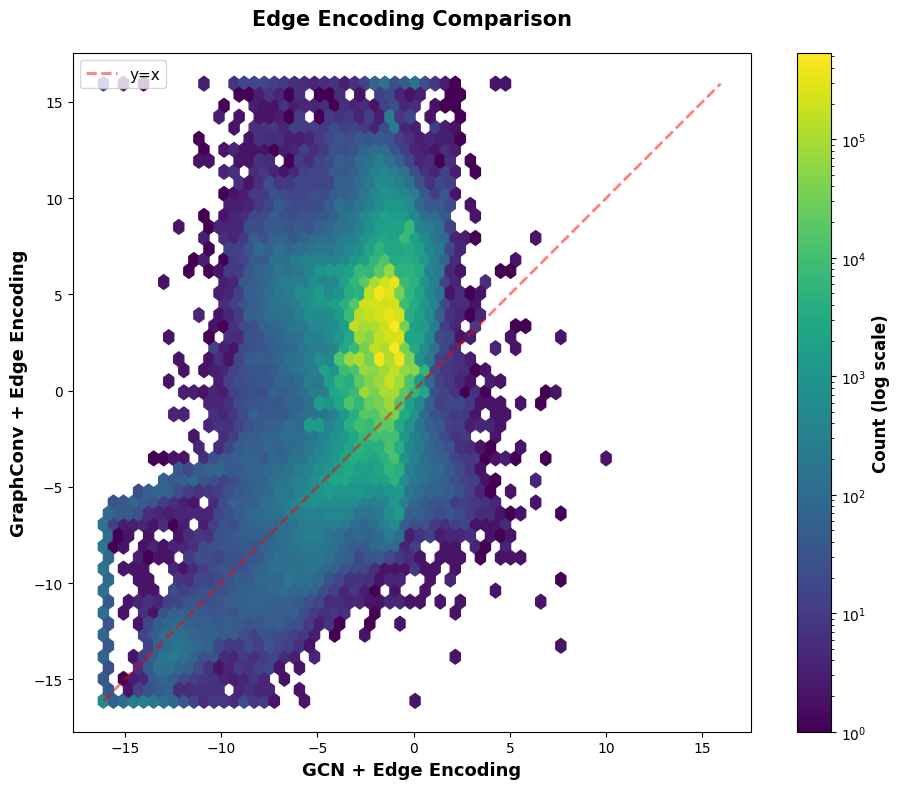

In [9]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.colors import LogNorm


def safe_logit(p: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    """
    Numerically stable logit transformation.
    
    Maps [0, 1] → (-∞, +∞) via log(p / (1 - p))
    
    Parameters
    ----------
    p : torch.Tensor
        Probabilities in range [0, 1]
    eps : float
        Small constant to avoid log(0) and division by zero
        
    Returns
    -------
    torch.Tensor
        Logit-transformed values on real number line
    """
    p = torch.clamp(p, eps, 1 - eps)
    return torch.log(p / (1 - p))


def plot_edge_encoding_hexbin(
    tensor1: torch.Tensor,
    tensor2: torch.Tensor,
    label1: str = "Model 1",
    label2: str = "Model 2",
    transform_to_logit: bool = True,
    gridsize: int = 50,
    cmap: str = 'viridis',
    figsize: tuple = (10, 8),
) -> tuple:
    """
    Create hexbin plot comparing two edge encoding tensors.
    
    Parameters
    ----------
    tensor1, tensor2 : torch.Tensor
        Edge encoding tensors to compare. Should be in [0, 1] if transform_to_logit=True.
    label1, label2 : str
        Labels for x and y axes
    transform_to_logit : bool
        If True, apply logit transformation to convert [0, 1] → (-∞, +∞)
    gridsize : int
        Number of hexagons in x-direction
    cmap : str
        Matplotlib colormap name
    figsize : tuple
        Figure size as (width, height)
        
    Returns
    -------
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
    """
    # Apply logit transformation if requested
    if transform_to_logit:
        tensor1 = safe_logit(tensor1)
        tensor2 = safe_logit(tensor2)
    
    # Convert to numpy
    if torch.is_tensor(tensor1):
        x = tensor1.cpu().numpy()
    else:
        x = np.array(tensor1)
    
    if torch.is_tensor(tensor2):
        y = tensor2.cpu().numpy()
    else:
        y = np.array(tensor2)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create hexbin plot with log-scaled color
    hexbin = ax.hexbin(
        x, y,
        gridsize=gridsize,
        cmap=cmap,
        mincnt=1,
        norm=LogNorm()
    )
    
    # Add colorbar
    cb = plt.colorbar(hexbin, ax=ax)
    cb.set_label('Count (log scale)', fontsize=12, fontweight='bold')
    
    # Labels and title
    ax.set_xlabel(label1, fontsize=13, fontweight='bold')
    ax.set_ylabel(label2, fontsize=13, fontweight='bold')
    ax.set_title('Edge Encoding Comparison', fontsize=15, fontweight='bold', pad=20)
    
    # Add diagonal reference line (y=x)
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            'r--', alpha=0.5, linewidth=2, label='y=x')
    ax.legend(loc='upper left', fontsize=11)
    
    # Equal aspect ratio
    ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    
    return fig, ax


# Usage
tensor1 = edge_encodings["GCN + Edge Encoding"]
tensor2 = edge_encodings["GraphConv + Edge Encoding"]

fig, ax = plot_edge_encoding_hexbin(
    tensor1,
    tensor2,
    label1="GCN + Edge Encoding",
    label2="GraphConv + Edge Encoding",
    transform_to_logit=True,
    gridsize=50,
    cmap='viridis'
)

plt.show()

Comparing the edge weights across the two models its apparent the low confidence edges are largely preserved between the two models while most edges are similarly treated as high confidence. (Note that the color scale is log-transformed so the vaste majority of edge weight pairs are near the distribution's mode.)

Having compared the five models its apparent that:
- the models are capturing similar edge- and vertex-centric signals
- predictive performance is greater for GraphConv/SAGE encoders than GCN
- edge encoders add some predictive benefits

Now, I will turn my attention to interpreting the top-model, GraphConv with an edge encoder. While this model is unoptimized (little hyperparameter exploration and using an unexpressive head) it will nevertheless help to explore the biological promise and limitations of the model. 

## Evaluating the GraphConv with edge encoding model

I see three potential contributions of the GNN models supporting edge prediction tasks.

1. **Molecular similarity** - embeddings can group similar vertices (even if they are different node and species types) enabling both community detection (clustering) and direct assessment of suprising clusters (e.g., what proteins is a drug most similar to). (The latter use cases is similar to how the dot-product head supports edge prediction, though a more sophisticated edge prediction head could learn more nuanced relationships between the from- and to-vertex embeddings.) 

2. **Learned edge weights** - learned edge weights could be incorporated into a NapistuGraph limiting the need for clunky heuristics. Edge weights are used extensively in network analysis (e.g., when calculating network layouts, shortest paths, network propagation, and even in shallow embedding methods like Node2Vec.) While developing these edge weights we can also assess what features make a high confidence edge to assess data source quality.

3. **Edge predictions** - While I was primarily interested in edge prediction because it is self-supervised, allowing me to train models which learn the tacit features of the network without needing ground-truth labels, edge predictions themselves may be useful. This could help to identify new regulatory connections especially once more expressive and/or relation-aware heads are added.

Here, I'll show some preliminary analyses in these three categories.

### Molecular similarity

#### Manifold structure

To assess the structure of the vertex embedding, I'll use the manifold learning approach, UMAP to visualize the embedding in two dimensions and then overlay vertex attributes (species types) to explore what determines "likeness" in the embedding.

/Users/sean/Desktop/GITHUB/shackett/posts/staging/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


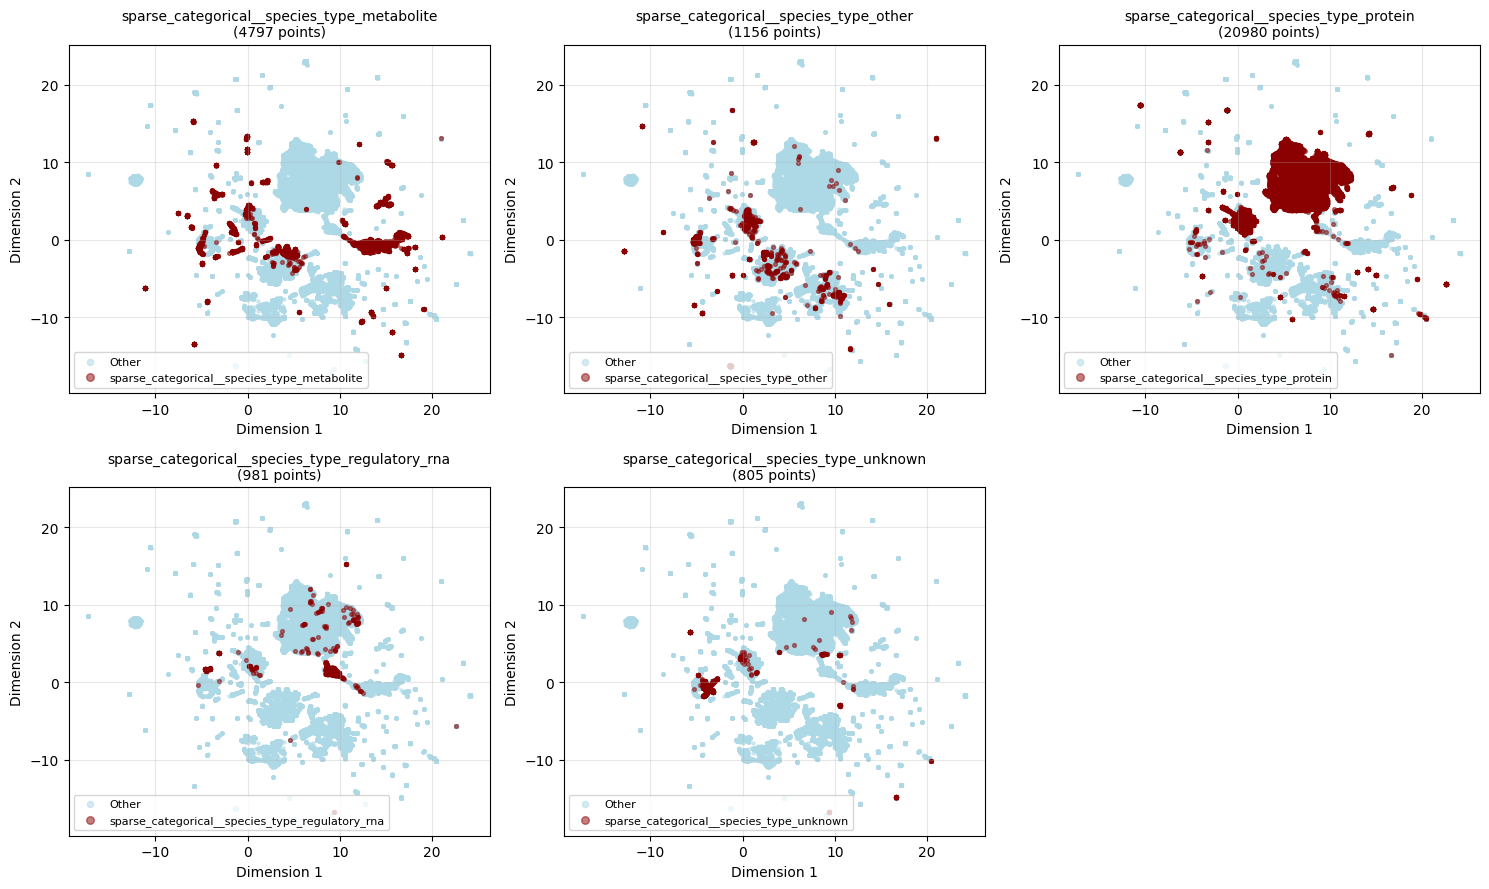

In [10]:
embeddings = species_embeddings[TOP_MODEL_NAME]
umap_layout_species = layout_umap(embeddings, n_neighbors=20)

mask = [bool(re.search("__species_type", x)) for x in napistu_data.get_vertex_feature_names()]
indices = [i for i, m in enumerate(mask) if m]
masks = napistu_data.x[:, indices]

# only look at the vertices with embedding values
masks = masks[is_species_mask]
mask_names = [x for x, m in zip(napistu_data.get_vertex_feature_names(), mask) if m]

# drop empty masks
empty_masks = masks.sum(axis=0) == 0
masks = masks[:, ~empty_masks]
mask_names = [x for x, m in zip(mask_names, ~empty_masks) if m]

fig, axes = plot_coordinates_with_masks(
    coordinates=umap_layout_species,
    masks=masks,  # Your tensor of masks
    mask_names=mask_names,
    figsize=(15, 9),
    ncols=3,
    cmap_bg='lightblue',
    cmap_fg='darkred',
    alpha=0.5,
    s=5
)

plt.show()

From the UMAP visualization it is apparent that proteins tend to be nearby other proteins and metabolites tend to be nearby other metabolites in the embedding space. This isn't really suprising since the input data sources are strongly homophilic (prefernetially linkage of similar categories of nodes), for example 80% of the edges in the network are from STRING and STRING edges are exclusively between pairs of proteins. Still, this layout is much "better mixed" than a layout generated using a shallow embedding approach like Node2Vec (TO DO - show plot). This suggests that while species type is a prominent feature of the embedding, other dimensions of the embedding capture complementary aspects of the graph's architecture.

To explore this, we can assess how data sources and biological pathways membership are relfected in the embedding.

#### Pathway similarity

To assess pathway similarity, I'll use the extended table of vertex pathway membership ("comprehensive_pathway_memberships") which was previously constructed using `ensure_artifacts`. This is a binary Tensor defining the coarse grain sources (8 sources) and fine-grained pathway membership (2800+ Reactome pathways) associations of each vertex. 

Using `calculate_pathway_similarities` I'll calculate the within category average cosine similarity for each source/pathway. Then I'll aggregate the fine-grained pathways to assess whether pathways tend to have similar embeddings even if their composite (the full Reactome source) is only loosly structured. 

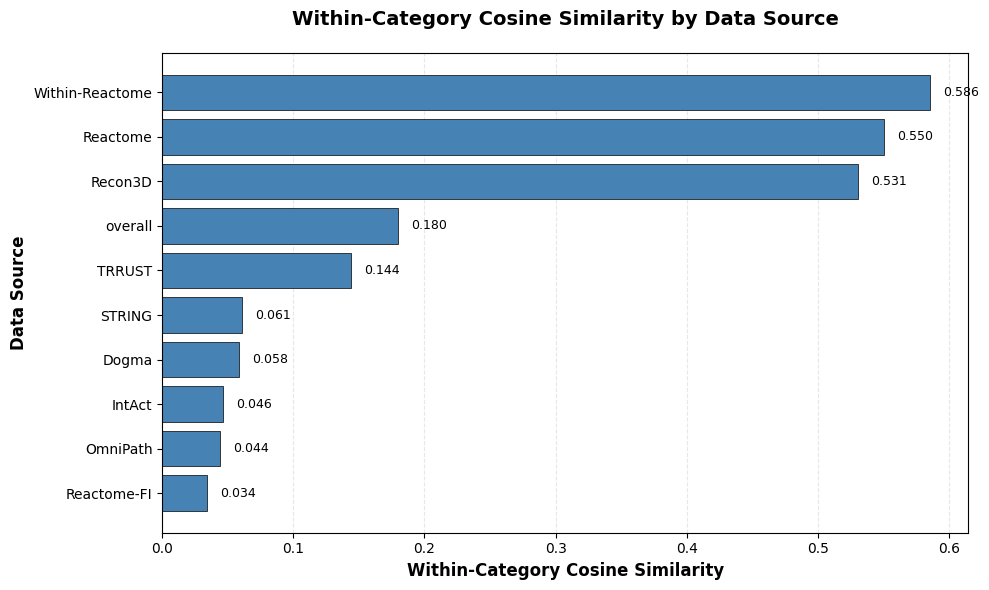

In [11]:
# not really needed, but we can check artifacts alignments to the canonical vertex and edge feature names from the NapistuData instance
pathway_assignments = comprehensive_pathway_memberships.align_to_napistu_data(napistu_data, inplace=False).data

pathway_similarities = calculate_pathway_similarities(
    embedding_matrix = embeddings,
    pathway_assignments = pathway_assignments[is_species_mask],
    pathway_names = comprehensive_pathway_memberships.feature_names,
)
# rename "other" to "Within-Reactome"
pathway_similarities["Within-Reactome"] = pathway_similarities.pop("other")

# Sort by value
sorted_items = sorted(pathway_similarities.items(), key=lambda x: x[1])
categories = [item[0] for item in sorted_items]
values = [item[1] for item in sorted_items]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create barplot
bars = ax.barh(categories, values, color='steelblue', edgecolor='black', linewidth=0.5)

# Customize the plot
ax.set_xlabel('Within-Category Cosine Similarity', fontsize=12, fontweight='bold')
ax.set_ylabel('Data Source', fontsize=12, fontweight='bold')
ax.set_title('Within-Category Cosine Similarity by Data Source', 
             fontsize=14, fontweight='bold', pad=20)

# Add value labels on the bars
for i, (cat, val) in enumerate(zip(categories, values)):
    ax.text(val + 0.01, i, f'{val:.3f}', 
            va='center', fontsize=9)

# Add grid for easier reading
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Here, overall, is the pair-weighted average so categories with more members (like Reactome) contribute more pairs.

These results provide an interesting complement the UMAP with species_type overlaid. It seems like while proteins tend to cluster in a big "glob" in the UMAP there is considerable variability in actual protein embeddings. In contrast, the more specialized data sources Reactome (which adds distinctive complexes, proteoforms and other detailed mechanisms) and Recon3D (which is a detailed metabolic model) are easily distinguished from the other molecular species in their embeddings. The Reactome species' embeddings do not differ greatly across pathways suggesting that the models are not capturing the detailed molecular mechanisms in Reactome. This is not particularly surpising since from a message passing perspective the vaste majority of edges are protein-protein so capturing the structure of protein interactions has a greater impact on training loss and validation AUC.

### Learned edge weights

Next, I'll explore what makes a high confidence edge using a simple saliency analysis.

The edge encoder takes a set of edge attributes (69 in this case) and converts them to a single (0, 1) weight. To evaluate the importance of each edge attributes I'll calculating its gradient / partial derivative with respect to the edge weight.

In [ ]:
device = select_device(mps_valid = True)

top_model = top_model_manager.load_model_from_checkpoint(top_model_manager.best_checkpoint_path)
edge_encoder = get_edge_encoder(top_model)
feature_sensitivities = compute_edge_feature_sensitivity(edge_encoder, napistu_data.edge_attr, 1000000, device)

ordered_feature_sensitivities = pd.DataFrame({
    "feature_name" : napistu_data.get_edge_feature_names(),
    "sensitivity" : feature_sensitivities.numpy()    
}).assign(
    absolute_sensitivity = lambda x: x["sensitivity"].abs()
).sort_values("absolute_sensitivity", ascending=False)


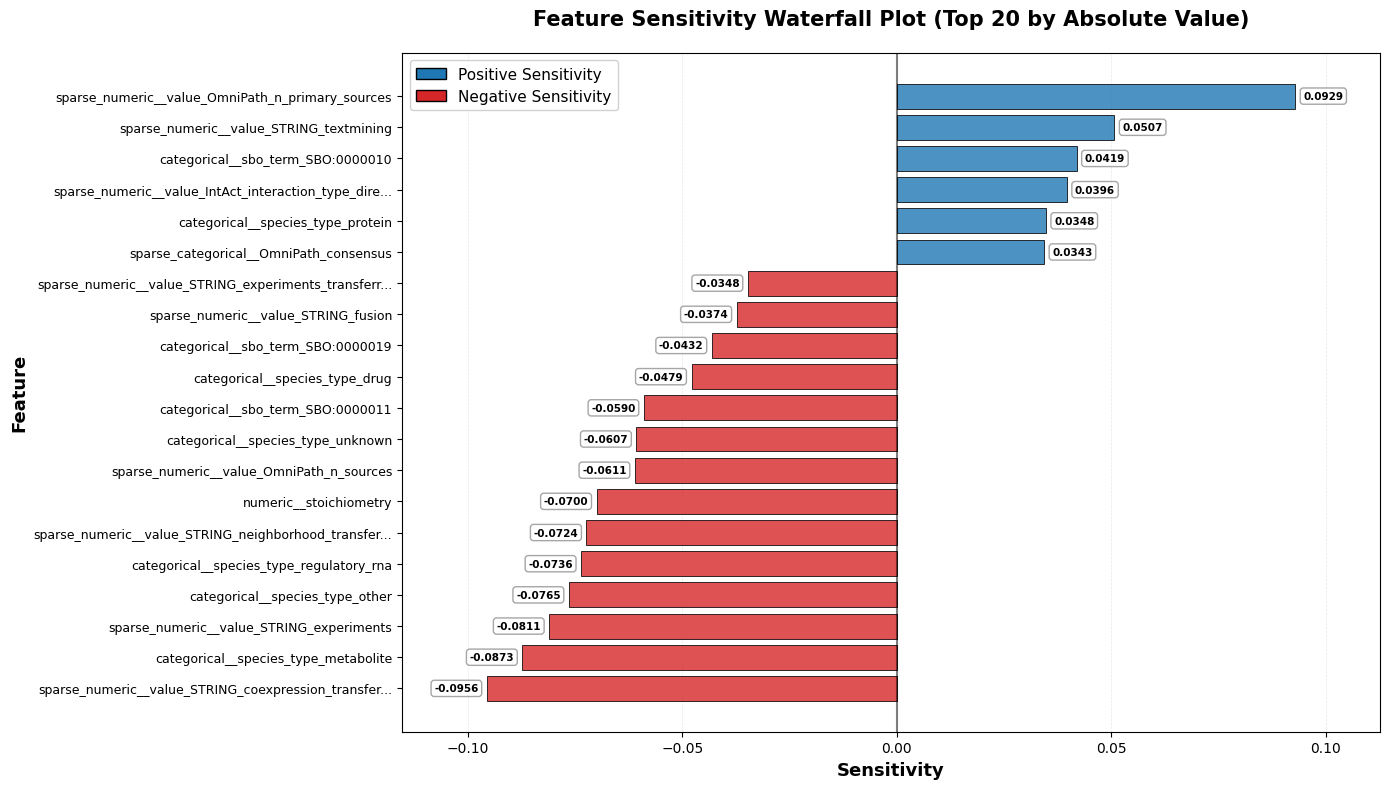

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

def create_signed_waterfall_plot(df, top_n=20, figsize=(16, 8), 
                                 truncate_names=50, output_path=None):
    """
    Create a signed waterfall plot for feature sensitivities.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: feature_name, sensitivity, absolute_sensitivity
    top_n : int
        Number of top features to display (by absolute sensitivity)
    figsize : tuple
        Figure size (width, height)
    truncate_names : int or None
        Maximum length for feature names. None = no truncation
    output_path : str or None
        Path to save the figure. If None, displays interactively
    """
    # Ensure we have the right columns
    required_cols = ['feature_name', 'sensitivity', 'absolute_sensitivity']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")
    
    # Sort by absolute sensitivity and get top N
    df_sorted = df.nlargest(top_n, 'absolute_sensitivity').copy()
    
    # Sort by sensitivity (signed) for plotting order
    df_sorted = df_sorted.sort_values('sensitivity', ascending=True)
    
    # Optionally truncate feature names
    if truncate_names:
        df_sorted['display_name'] = df_sorted['feature_name'].apply(
            lambda x: x[:truncate_names] + '...' if len(x) > truncate_names else x
        )
    else:
        df_sorted['display_name'] = df_sorted['feature_name']
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get values
    sensitivities = df_sorted['sensitivity'].values
    feature_names = df_sorted['display_name'].values
    
    # Create color map: positive = blue, negative = red
    colors = ['#d62728' if x < 0 else '#1f77b4' for x in sensitivities]
    
    # Create bar positions
    y_pos = np.arange(len(feature_names))
    
    # Create horizontal bars
    bars = ax.barh(y_pos, sensitivities, color=colors, edgecolor='black', 
                   linewidth=0.7, alpha=0.8)
    
    # Customize plot
    ax.set_ylabel('Feature', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sensitivity', fontsize=13, fontweight='bold')
    ax.set_title(f'Feature Sensitivity Waterfall Plot (Top {top_n} by Absolute Value)', 
                 fontsize=15, fontweight='bold', pad=20)
    
    # Set y-axis
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names, fontsize=9)
    
    # Add vertical line at x=0
    ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-', alpha=0.5)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, sensitivities)):
        width = bar.get_width()
        # Position label to the right/left of bar
        offset = max(abs(sensitivities)) * 0.02
        label_x = width + (offset if width > 0 else -offset)
        ha = 'left' if width > 0 else 'right'
        ax.text(label_x, bar.get_y() + bar.get_height()/2.,
                f'{val:.4f}',
                ha=ha, va='center', fontsize=7.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor='gray', alpha=0.7))
    
    # Add legend
    legend_elements = [
        Patch(facecolor='#1f77b4', edgecolor='black', label='Positive Sensitivity'),
        Patch(facecolor='#d62728', edgecolor='black', label='Negative Sensitivity')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.9)
    
    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Adjust x-axis limits to accommodate labels
    x_min, x_max = ax.get_xlim()
    x_range = x_max - x_min
    ax.set_xlim(x_min - x_range * 0.05, x_max + x_range * 0.05)
    
    # Tight layout
    plt.tight_layout()
    
    # Save or show
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {output_path}")
    
    return fig, ax

# Create plot
fig, ax = create_signed_waterfall_plot(ordered_feature_sensitivities, top_n=20, figsize=(14, 8))
plt.show()

Finally, I'll explore the types of edges being predicted by the GraphConv GNN.

### Edge predictions

As I previously discussed, if negative samples are too dissimilar to real edges the model can focus on vertex attributes which may reveal unlikely or impossible edges rather than learning the biologically meaningful network structure. To combat this, negative samples were generated using the observed node_type strata (i.e., recovering an equal number of species -> species, species -> reaction and reaction -> species edges as the real set of edges). But, there are other vertex features which may trivially distinguish real and fake edges such as there being zero cases of regulatory RNAs interacting with metabolites in the dataset. 

To assess whether the model is learning to capitilize on a potential lack of calibration between real vertices and negative samples, I'll compare the model's predicted edge probabilities for individual classes of edges to what would be expected just based on how common that type of edge is among real edges compared to negative samples.


Restoring states from the checkpoint path at /Users/sean/Desktop/EXPERIMENTS/20251106_edge_prediction/20251106_graphconv_edge_encoding/checkpoints/best-epoch=199-val_auc=0.7890.ckpt
/Users/sean/Desktop/GITHUB/shackett/posts/staging/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/call.py:283: Be aware that when using `ckpt_path`, callbacks used to create the checkpoint need to be provided during `Trainer` instantiation. Please add the following callbacks: ["ModelCheckpoint{'monitor': 'val_auc', 'mode': 'max', 'every_n_train_steps': 0, 'every_n_epochs': 1, 'train_time_interval': None}", "EarlyStopping{'monitor': 'val_auc', 'mode': 'max'}"].
Loaded model weights from the checkpoint at /Users/sean/Desktop/EXPERIMENTS/20251106_edge_prediction/20251106_graphconv_edge_encoding/checkpoints/best-epoch=199-val_auc=0.7890.ckpt
/Users/sean/Desktop/GITHUB/shackett/posts/staging/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'predict_d

Predicting DataLoader 0: 100%|██████████| 1/1 [00:05<00:00,  0.18it/s]


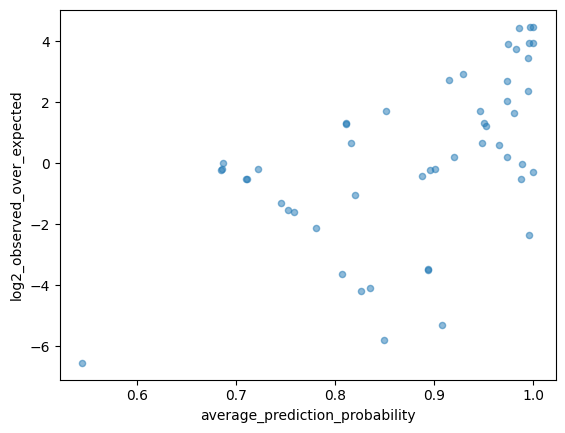

In [20]:
edge_predictions = predict(
    top_model_manager.get_experiment_dict(),
    checkpoint=top_model_manager.best_checkpoint_path
)

species_strata_recovery = summarize_edge_predictions_by_strata(edge_predictions, edge_strata_by_node_species_type)
# species_strata_recovery["logit_average_prediction_probability"] = safe_logit(torch.Tensor(species_strata_recovery["average_prediction_probability"]))
species_strata_recovery["log2_observed_over_expected"] = np.log2(species_strata_recovery["observed_over_expected"])

# scatterplot log2_average_prediction_probability vs log2_observe_over_expected
species_strata_recovery.plot.scatter(x="average_prediction_probability", y="log2_observed_over_expected", alpha=0.5)
plt.show()

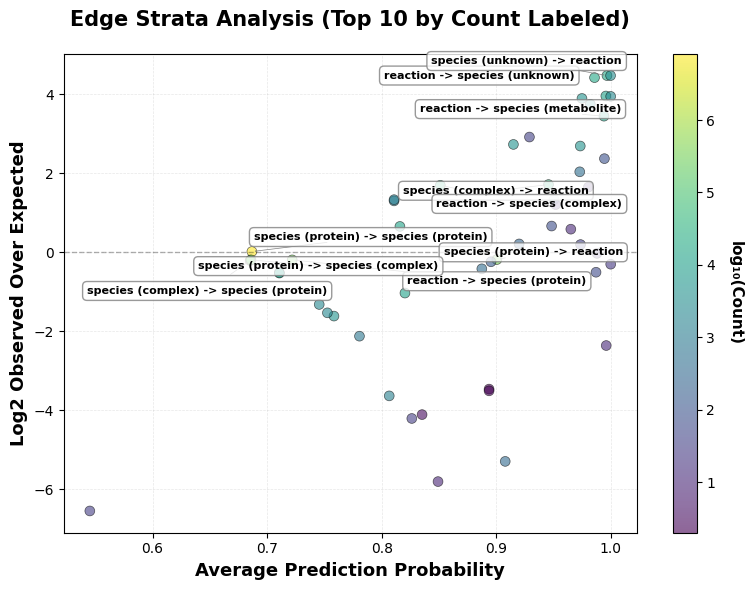

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

def create_enhanced_scatter(
    df, 
    x_col='average_prediction_probability',
    y_col='log2_observed_over_expected',
    size_col='count',
    label_col='edge_strata',
    top_k=10,
    figsize=(8, 6),
    alpha=0.6
):
    """
    Create an enhanced scatter plot with sized points and labeled top K entries.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing the data
    x_col : str
        Column name for x-axis
    y_col : str
        Column name for y-axis
    size_col : str
        Column name for point sizes
    label_col : str
        Column name for point labels
    top_k : int
        Number of top points to label (by size_col)
    figsize : tuple
        Figure size (width, height)
    size_scale : float
        Scaling factor for point sizes
    alpha : float
        Transparency of points (0-1)
    output_path : str or None
        Path to save figure. If None, displays interactively
    """
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create color map based on log-transformed count values using viridis
    colors = np.log10(df[size_col] + 1)
    
    # Create scatter plot
    scatter = ax.scatter(df[x_col], 
                        df[y_col],
                        s=50,
                        c=colors,
                        cmap='viridis',  # Viridis colormap
                        alpha=alpha,
                        edgecolors='black',
                        linewidth=0.5)
    
    # Add colorbar with better labeling
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(f'log₁₀({size_col.replace("_", " ").title()})', 
                   rotation=270, labelpad=20, fontsize=11, fontweight='bold')
    
    # Get top K points by count
    top_k_indices = df.nlargest(top_k, size_col).index
    
    # Add labels for top K points
    texts = []
    for idx in top_k_indices:
        row = df.loc[idx]
        label = row[label_col]
        # Shorten label if too long
        if len(str(label)) > 40:
            label = str(label)[:37] + '...'
        
        texts.append(
            ax.text(row[x_col], 
                   row[y_col],
                   label,
                   fontsize=8,
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4', 
                            facecolor='white', 
                            edgecolor='gray',
                            alpha=0.8))
        )
    
    # Adjust text positions to avoid overlap
    try:
        adjust_text(texts,
                   arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
                   ax=ax)
    except:
        # If adjustText not available or fails, just continue
        pass
    
    # Add reference lines
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.3)
    
    # Labels and title
    ax.set_xlabel(x_col.replace('_', ' ').title(), 
                 fontsize=13, fontweight='bold')
    ax.set_ylabel(y_col.replace('_', ' ').title(), 
                 fontsize=13, fontweight='bold')
    ax.set_title(f'Edge Strata Analysis (Top {top_k} by Count Labeled)', 
                fontsize=15, fontweight='bold', pad=20)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    return fig, ax

fig, ax = create_enhanced_scatter(species_strata_recovery)
plt.show()